# 02 Modelling, evaluation and uncertainty
Runs the same code as `python -m speedy.train` (`speedy.evaluate.run_evaluation`) and shows the evidence. Methodology:
* 5 contiguous 13-week out-of-fold blocks (last 65 weeks). Blend weights for block *j* are chosen **only from blocks before j** (walk-forward nested selection), so the estimate covers the whole selection procedure.
* Headline metrics carry **95% moving-block bootstrap CIs** (bootstrap over weeks, in blocks, because weekly errors are autocorrelated).
* Improvement over the naive benchmark is tested with a **paired** bootstrap.
* A separate 58-week "year-ahead" check mirrors the real horizon. It is **one** sample.

In [1]:
import sys, warnings; sys.path.insert(0, "../src"); warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from speedy.config import DATA_DIR, MODEL_PATH
from speedy.data import load_panel, to_wide
from speedy.features import build_features, FEATURE_COLUMNS
print("data dir:", DATA_DIR)
from speedy.evaluate import run_evaluation
panel = load_panel(DATA_DIR)
res = run_evaluation(panel, prophet=True, n_boot=1000); arr = res.pop("_arrays")

data dir: /home/claude/data/Turing College Module 6/Speedy Forecasting


Importing plotly failed. Interactive plots will not work.


07:40:13 - cmdstanpy - INFO - Chain [1] start processing


07:40:13 - cmdstanpy - INFO - Chain [1] done processing


In [2]:
rows = []
for k, m in res["oof_metrics"].items():
    ci = {s: res["oof_ci"][s][k] for s in res["oof_ci"]}
    rows.append({"model": k, **{s: f"{ci[s][0]:.2%}  [{ci[s][1]:.2%}, {ci[s][2]:.2%}]" for s in ci}})
pd.DataFrame(rows).set_index("model")

,WMAPE,Bias,Weekly_total_MAPE
model,,,
blend_walk_forward,"4.89% [4.38%, 5.52%]","-2.35% [-3.36%, -1.53%]","3.01% [2.40%, 3.84%]"
seasonal_naive,"5.61% [5.24%, 6.21%]","-2.18% [-3.14%, -1.47%]","3.15% [2.57%, 4.11%]"
ridge_alpha1,"5.97% [5.38%, 6.68%]","-2.36% [-3.30%, -1.55%]","3.05% [2.43%, 3.90%]"
prophet,"6.15% [5.16%, 7.29%]","-1.19% [-3.26%, 1.31%]","4.48% [3.39%, 5.71%]"


In [3]:
d = res["oof_skill_vs_naive_WMAPE_diff"]["naive_minus_blend"]
print(f"WMAPE improvement of blend over seasonal naive: {d[0]:.2%} (95% CI {d[1]:.2%} to {d[2]:.2%}) -> {'distinguishable from noise' if d[1]>0 else 'NOT distinguishable from noise'}")
print("configs picked per block (alpha, w_naive, w_ridge, w_prophet, x10):", res["oof_cfgs"]); print("production config:", res["final_cfg"])

WMAPE improvement of blend over seasonal naive: 0.72% (95% CI 0.19% to 1.24%) -> distinguishable from noise
configs picked per block (alpha, w_naive, w_ridge, w_prophet, x10): [[1.0, 4.0, 3.0, 3.0], [10.0, 3.0, 5.0, 2.0], [10.0, 5.0, 2.0, 3.0], [10.0, 4.0, 3.0, 3.0], [10.0, 4.0, 3.0, 3.0]]
production config: [10.0, 4, 2, 4]


## Uncertainty, stated carefully
* **Bias is real, not noise:** all five quarter-level errors have the same sign (forecast too low).
* **Annual range is indicative:** based on n = 5 quarters, using a t-based predictive interval; quarters share a sign so they are treated as fully correlated.
* **Bands are checked out of sample:** calibrated on earlier blocks, scored on later ones.

In [4]:
q = np.array(res["quarter_total_error"]); print("quarter total error actual/forecast-1:", np.round(q,4), "| mean", q.mean().round(4))
print("annual planning range actual/forecast-1 (80%, indicative):", np.round(res["annual_planning_range"],4))
cc = res["coverage_check"]; print(f"80% store-week band: calibrated {cc['calibration_weeks']}, tested {cc['test_weeks']} -> coverage {cc['coverage_80']:.1%} (target 80%)")
print("year-ahead (58 wks, single sample):"); display(pd.DataFrame({k: v for k, v in res["year_ahead"].items() if k != "note"}).T)

quarter total error actual/forecast-1: [0.0309 0.0243 0.0387 0.0092 0.0181] | mean 0.0242
annual planning range actual/forecast-1 (80%, indicative): [0.0051 0.0433]
80% store-week band: calibrated ['2011-08-05', '2012-04-27'], tested ['2012-05-04', '2012-10-26'] -> coverage 89.1% (target 80%)
year-ahead (58 wks, single sample):


,WMAPE,MAPE,Bias,Store_annual_APE,Weekly_total_MAPE
equal_weights_untuned,0.052807,0.056216,-0.031379,0.04296,0.035839
selected_cfg,0.053098,0.056942,-0.031995,0.04380,0.036102
seasonal_naive,0.059310,0.063976,-0.027511,0.04701,0.035999


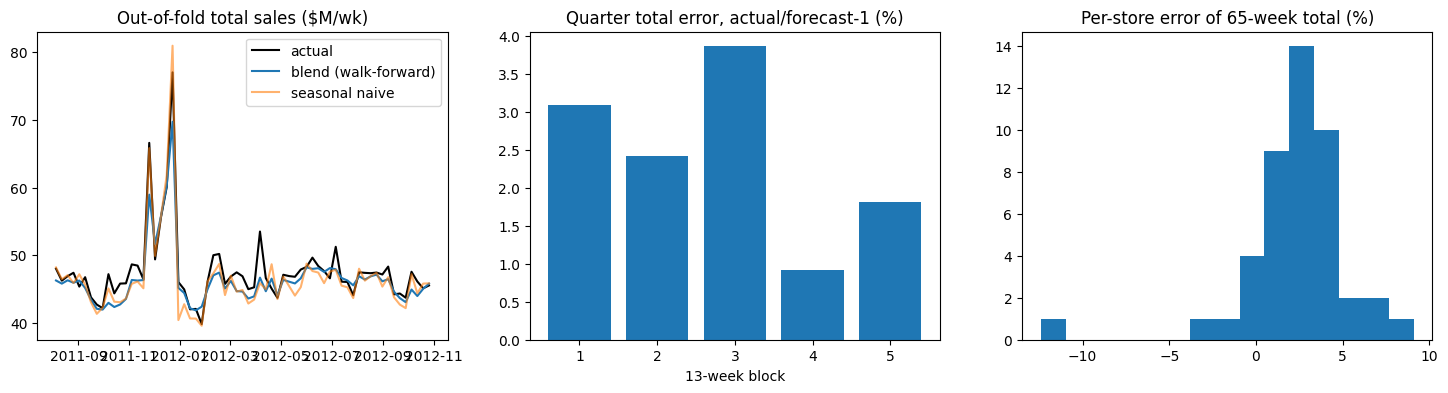

In [5]:
a, f = arr["oof_actual"], arr["oof_blend"]; nv = arr["oof_benchmarks"]["seasonal_naive"]
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
ax[0].plot(a.index, a.sum(axis=1)/1e6, "k", label="actual"); ax[0].plot(f.index, f.sum(axis=1)/1e6, label="blend (walk-forward)"); ax[0].plot(nv.index, nv.sum(axis=1)/1e6, alpha=.6, label="seasonal naive"); ax[0].legend(); ax[0].set_title("Out-of-fold total sales ($M/wk)")
ax[1].bar(range(1,6), q*100); ax[1].axhline(0, c="k", lw=.5); ax[1].set_title("Quarter total error, actual/forecast-1 (%)"); ax[1].set_xlabel("13-week block")
e = (a.sum()/f.sum()-1)*100; ax[2].hist(e, bins=15); ax[2].set_title("Per-store error of 65-week total (%)"); plt.show()

## Final forecast from the persisted artefact (`models/forecaster.joblib`)
Run `python -m speedy.train` first. Scoring uses only the artefact, not the raw data.

{'version': '1.0.0', 'trained_through': '2012-10-26', 'n_weeks': 143, 'n_stores': 45, 'sklearn': '1.8.0', 'python': '3.12.3', 'params': {'alpha': 10.0, 'cps': 0.05, 'fourier': 5, 'n_jobs': 1, 'use_trend': True, 'w_naive': 0.4, 'w_prophet': 0.4, 'w_ridge': 0.2}}


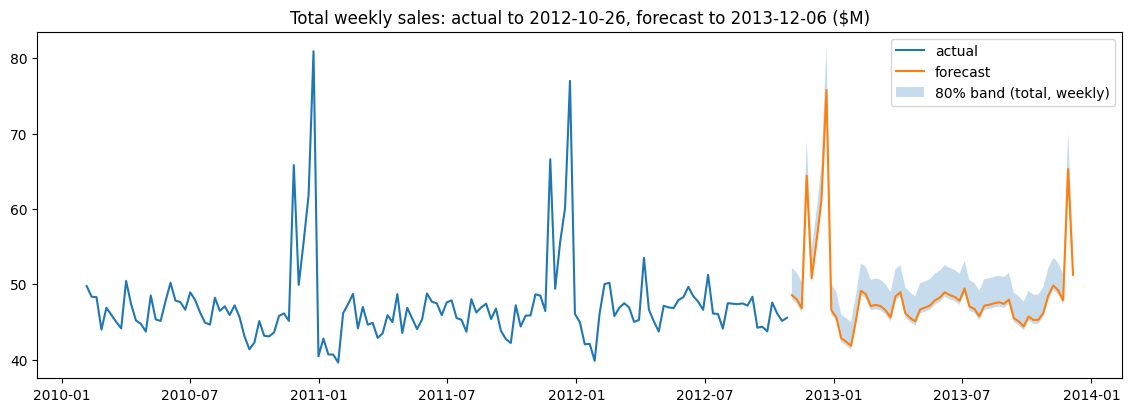

2013 weeks in horizon: $2,317M; indicative range $2,329M .. $2,417M


In [6]:
from speedy.inference import load_artifact, forecast_weekly, forecast_totals
art = load_artifact(MODEL_PATH); w = forecast_weekly(art, "2013-12-06"); t = forecast_totals(art, w); print(art["metadata"])
fig, ax = plt.subplots(figsize=(14, 4.5)); wide = to_wide(panel); ax.plot(wide.index, wide.sum(axis=1)/1e6, label="actual")
ax.plot(t.Date, t.Forecast/1e6, label="forecast"); ax.fill_between(t.Date, t.Lower80/1e6, t.Upper80/1e6, alpha=.25, label="80% band (total, weekly)")
ax.set_title("Total weekly sales: actual to 2012-10-26, forecast to 2013-12-06 ($M)"); ax.legend(); plt.savefig("../outputs/forecast_plot.png", dpi=120, bbox_inches="tight"); plt.show()
y13 = t[t.Date.dt.year==2013].Forecast.sum(); lo, hi = res["annual_planning_range"]
print(f"2013 weeks in horizon: ${y13/1e6:,.0f}M; indicative range ${y13*(1+lo)/1e6:,.0f}M .. ${y13*(1+hi)/1e6:,.0f}M")